# Keyword Extraction

## Goal
Given a document, automatically identify the most important words.
No labels. No training. Just the text itself.

## Approach
TF-IDF scores tell us which words are important in a document
relative to a corpus. We use those scores as keyword rankings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer


## 1. Define Documents
Three documents on different topics.

In [2]:
documents = {
    "ML": """
        Machine learning is a subset of artificial intelligence.
        It enables computers to learn from data without being explicitly programmed.
        Deep learning uses neural networks with many layers to learn complex patterns.
        Training a machine learning model requires large amounts of labeled data.
    """,
    "Climate": """
        Climate change is one of the most pressing issues of our time.
        Rising temperatures are causing glaciers to melt and sea levels to rise.
        Renewable energy sources like solar and wind power can reduce carbon emissions.
        Governments and industries must work together to address climate change.
    """,
    "Cooking": """
        Cooking is both an art and a science.
        Understanding the chemistry of ingredients helps create better dishes.
        Temperature control is crucial when baking bread or making pastries.
        Fresh ingredients always produce better results than processed ones.
    """
}

print(f"Documents: {list(documents.keys())}")

Documents: ['ML', 'Climate', 'Cooking']


## 2. Extract Keywords with TF-IDF

In [5]:
def extract_keywords(doc: str, corpus: list, vectorizer, top_n: int = 5) -> list:
    """Extract top keywords from a document using TF-IDF scores."""
    tfidf_matrix = vectorizer.transform([doc])
    feature_names = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.toarray()[0]

    top_indices = scores.argsort()[::-1][:top_n]
    keywords = [(feature_names[i], scores[i]) for i in top_indices if scores[i] > 0]
    return keywords

# Fit vectorizer on all documents
corpus = list(documents.values())
vectorizer = TfidfVectorizer(stop_words="english")
vectorizer.fit(corpus)

# Extract keywords for each document
print(f"{'Document':<12} {'Keyword':<20} {'Score':>8}")
print("-" * 42)
for doc_name, doc_text in documents.items():
    keywords = extract_keywords(doc_text, corpus, vectorizer)
    for i, (word, score) in enumerate(keywords):
        label = doc_name if i == 0 else ""
        print(f"{label:<12} {word:<20} {score:>8.4f}")

    print()

Document     Keyword                 Score
------------------------------------------
ML           learning               0.4685
             machine                0.3123
             data                   0.3123
             learn                  0.3123
             training               0.1562

Climate      change                 0.3482
             climate                0.3482
             work                   0.1741
             industries             0.1741
             power                  0.1741

Cooking      ingredients            0.3780
             better                 0.3780
             results                0.1890
             helps                  0.1890
             fresh                  0.1890



## 3. Visualize Keywords

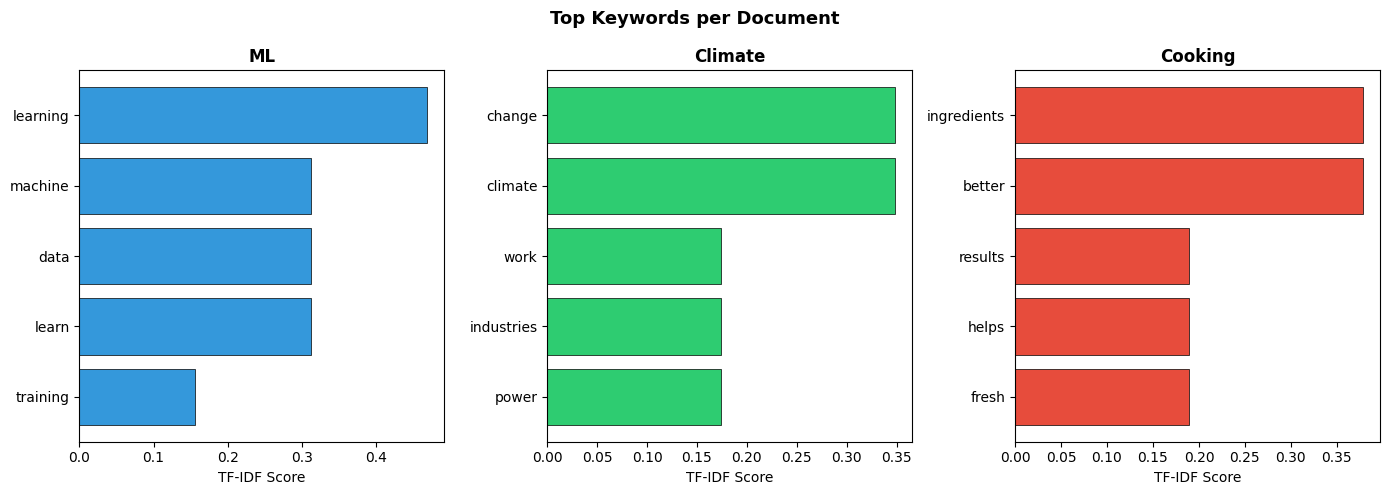

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#3498db", "#2ecc71", "#e74c3c"]

for ax, (doc_name, doc_text), color in zip(axes, documents.items(), colors):
    keywords = extract_keywords(doc_text, corpus, vectorizer)
    words, scores = zip(*keywords)

    ax.barh(words[::-1], scores[::-1], color=color, edgecolor="black", linewidth=0.5)
    ax.set_title(f"{doc_name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("TF-IDF Score")

plt.suptitle("Top Keywords per Document", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("keyword_extraction.png", dpi=300)
plt.show()

## 4. Key Observations

| Document | Top Keywords | Quality |
|----------|-------------|---------|
| ML | learning, machine, data | Excellent — core ML terms |
| Climate | change, climate | Good — but "work", "power" are weak |
| Cooking | ingredients, better | Mixed — "better" is not topic-specific |

## Key Insight
TF-IDF keyword extraction works well for topic-specific vocabulary.
It struggles when important words are common across documents.
"better" ranks high in Cooking because it appears often there,
but it carries no real topic signal.

## Limitation
TF-IDF treats all words as independent.
It cannot understand that "neural networks" and "deep learning"
belong to the same topic without sharing exact words.

## Next
-> text_clustering.ipynb